# 3 - Diagnóstico do modelo final

## Objetivo

Emitir o **atestado de sanidade** do `gain_best` antes de declarar a Etapa 4 encerrada: convergência, mode collapse, distribuições imputadas, comportamento por variável e por estação. O RMSE já foi julgado no notebook 2 (0,2317 vs 0,2742 do KNN — critério de aceite atendido); aqui a pergunta é outra.

> **Pergunta que responde:** o modelo escolhido é estatisticamente saudável ou apresenta patologias (modo colapsado, viés sistemático, comportamento estranho em alguma variável ou estação)?

## Posição na Etapa 4

Notebook **3 de 3** — o último. Inputs: `checkpoints/gain_best.pt` + `Data/GainResults/config_best.json` (contrato do notebook 2). Saída além das figuras: `Data/GainResults/diagnostico.md`, o relatório narrativo com o veredicto **avançar para a Etapa 5 ou voltar ao notebook 2**.

## Patologias clássicas de GAN que vamos checar

1. **Não-convergência / oscilação** — perdas divergindo ou saltando nos últimos 20% do treino.
2. **Dominância do discriminador** — `loss_D → 0` (o D "ganha" e o gradiente do G morre).
3. **Mode collapse** — imputações quase constantes, ignorando o contexto; medido pela *diversidade entre amostras* (desvio-padrão das imputações vs dos valores reais) e pela sensibilidade ao ruído $Z$.
4. **Encolhimento de variância / regressão à média** — patologia esperada em modelos selecionados por RMSE (e o `beta=10` empurra nessa direção): imputações certas *em média*, mas com caudas comprimidas.
5. **Viés sistemático** — resíduo mediano longe de zero em alguma variável ou estação.

## Notas de implementação

- **Log de treino regenerado por retreino determinístico.** O notebook 2 não persistiu o log do treino final; como `train_gain` é totalmente seedado (torch CPU), retreinar com os mesmos hp e seed 42 reproduz o log — e a comparação com o `rmse_val` registrado em `config_best.json` vira uma **verificação de reprodutibilidade** de graça.
- **Espaço normalizado [-1, 1]** em todas as análises de erro — comparável entre variáveis e é o espaço da métrica de decisão (RMSE_norm).
- **Células diagnósticas com verdade conhecida**: as escondidas `(M=1, B=0)` das **3 seeds do protocolo** da Etapa 3 agrupadas (~200 células) — mais estatística que a `B` única da curva de treino (68).
- **Caminhos reais** (convenção dos notebooks 1–2): dados em `Data/GoldData/`, figuras em `Data/Figures/04_GAIN/`, relatório em `Data/GainResults/diagnostico.md`.

## Setup

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

sys.path.append("../3 - Preprocessing")
sys.path.append("../4 - Baseline")
from mask_utils import generate_artificial_mask
import baseline_utils as bu
import gain

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

IN_SPLIT_DIR    = Path("../../Data/GoldData/Splited")
IN_MASK_DIR     = Path("../../Data/GoldData/Masked")
IN_COLUMNS_JSON = Path("../../Data/ProcessedData/encoded_columns.json")
IN_CKPT         = Path("./checkpoints/gain_best.pt")
IN_CONFIG       = Path("../../Data/GainResults/config_best.json")

OUT_RES_DIR = Path("../../Data/GainResults")
OUT_FIG_DIR = Path("../../Data/Figures/04_GAIN")
OUT_RELATORIO = OUT_RES_DIR / "diagnostico.md"

# Cores do projeto (notebooks 1-2)
AZUL, LARANJA, CINZA = "#4269d0", "#efb118", "#9e9e9e"
INK, MUTED, GRADE = "#0b0b0b", "#898781", "#e1e0d9"

# Checkpoint interno do projeto (gerado por 02_hyperparam.ipynb) — só tipos simples + tensores
ckpt = torch.load(IN_CKPT, weights_only=True)
with open(IN_CONFIG, encoding="utf-8") as f:
    config_best = json.load(f)

hp = ckpt["hp"]
VARS, CONTEXT_COLS = ckpt["vars"], ckpt["context_cols"]
G = gain.Generator(len(VARS), len(CONTEXT_COLS), hp["hidden"])
G.load_state_dict(ckpt["G_state"])
G.eval()

print(f"gain_best carregado: {config_best['config_id']} | seed {ckpt['seed']} | "
      f"iteração {ckpt['iteracao_melhor']}")
print(f"hp: { {k: v for k, v in hp.items()} }")
print(f"rmse_val (curva): {config_best['rmse_val_curva_norm']:.4f} | "
      f"protocolo Etapa 3: {config_best['rmse_val_protocolo_etapa3']:.4f}")

gain_best carregado: cfg_1092 | seed 42 | iteração 1000
hp: {'hint_rate': 0.9, 'alpha': 10.0, 'beta': 10.0, 'batch_size': 128, 'hidden': [128, 128], 'lr_g': 0.001, 'lr_d': 0.001, 'n_iter': 5000}
rmse_val (curva): 0.2355 | protocolo Etapa 3: 0.2317


## Carregamento dos dados

Tensores como nos notebooks 1–2, mais a série de estação de cada coleta do val (recuperada do one-hot `est_*`) para a análise por estação.

In [2]:
with open(IN_COLUMNS_JSON, encoding="utf-8") as f:
    encoded_columns = json.load(f)
assert VARS == encoded_columns["numericas"], "checkpoint e encoded_columns divergem"

df_train = pd.read_parquet(IN_SPLIT_DIR / "train.parquet")
df_val   = pd.read_parquet(IN_SPLIT_DIR / "val.parquet")
mask_real_train = pd.read_parquet(IN_MASK_DIR / "mask_real_train.parquet")
mask_real_val   = pd.read_parquet(IN_MASK_DIR / "mask_real_val.parquet")

def para_tensores(df, mask):
    x   = torch.tensor(df[VARS].fillna(0.0).to_numpy(dtype=np.float32))
    m   = torch.tensor(mask[VARS].to_numpy(dtype=np.float32))
    ctx = torch.tensor(df[CONTEXT_COLS].to_numpy(dtype=np.float32))
    return x, m, ctx

x_train, m_train, ctx_train = para_tensores(df_train, mask_real_train)
x_val,   m_val,   ctx_val   = para_tensores(df_val, mask_real_val)

estacao_val = bu.coluna_estacao(df_val)

ROBUSTAS = ["DBO", "OD", "pH", "Turbidez", "Temperatura da Água",
            "Condutividade", "Fósforo Total"]
INTERMEDIARIAS = ["Nitrato", "Nitrogênio Amoniacal Total", "Coliformes Termotolerantes"]
CRITICAS = ["Sólidos Suspensos Totais"]
MISS_RATES_PADRAO = {**{v: 0.20 for v in ROBUSTAS},
                     **{v: 0.10 for v in INTERMEDIARIAS},
                     **{v: 0.05 for v in CRITICAS}}
miss_rates_vec = np.array([MISS_RATES_PADRAO[v] for v in VARS], dtype=np.float32)

B_val = generate_artificial_mask(mask_real_val, miss_rate=0.20, seed=SEED)
b_val = torch.tensor(B_val.to_numpy(dtype=np.float32))

# Rótulos curtos para as figuras
ABREV = {"DBO": "DBO", "OD": "OD", "Nitrato": "Nitrato",
         "Nitrogênio Amoniacal Total": "N-Amoniacal", "Fósforo Total": "P-Total",
         "Condutividade": "Condutiv.", "pH": "pH", "Turbidez": "Turbidez",
         "Temperatura da Água": "Temp. Água", "Sólidos Suspensos Totais": "SST",
         "Coliformes Termotolerantes": "Coliformes"}

print(f"val: {len(df_val)} coletas | estações: {sorted(estacao_val.unique())}")
print(f"células faltantes reais no val (M=0): {int((m_val == 0).sum())} "
      f"de {m_val.numel()} ({100 * float((m_val == 0).float().mean()):.1f}%)")

val: 34 coletas | estações: ['CM320', 'JC342', 'MR361', 'MR369', 'TJ303', 'TJ306']
células faltantes reais no val (M=0): 75 de 374 (20.1%)


## Análise de convergência

Retreino determinístico (mesmos hp, seed 42, mesma `B` fixa de validação) para regenerar o `training_log` do modelo final. O menor `rmse_val` do log deve **bater exatamente** com o `config_best.json` — se bater, o pipeline é reprodutível; se não, temos um problema maior que convergência.

In [3]:
%%time
G_re, D_re, training_log = gain.train_gain(
    x_train, m_train, ctx_train, hp, miss_rates=miss_rates_vec,
    val_data=(x_val, m_val, ctx_val, b_val), seed=ckpt["seed"], eval_every=100)

melhor = training_log.loc[training_log["rmse_val"].idxmin()]
diff = abs(float(melhor["rmse_val"]) - config_best["rmse_val_curva_norm"])
reproduzivel = diff < 1e-6
print(f"melhor rmse_val do retreino: {melhor['rmse_val']:.6f} @ iter {int(melhor['iteracao'])}")
print(f"config_best.json:            {config_best['rmse_val_curva_norm']:.6f} "
      f"@ iter {config_best['iteracao_melhor']}")
print(f"reprodutível (diff < 1e-6): {'SIM' if reproduzivel else f'NÃO — diff={diff:.2e}'}")

training_log.to_csv(OUT_RES_DIR / "training_log_final.csv", index=False, encoding="utf-8")
print(f"log salvo: {OUT_RES_DIR / 'training_log_final.csv'} ({len(training_log)} registros)")

melhor rmse_val do retreino: 0.235511 @ iter 1000
config_best.json:            0.235511 @ iter 1000
reprodutível (diff < 1e-6): SIM
log salvo: ..\..\Data\GainResults\training_log_final.csv (51 registros)
CPU times: total: 3min 40s
Wall time: 19.5 s


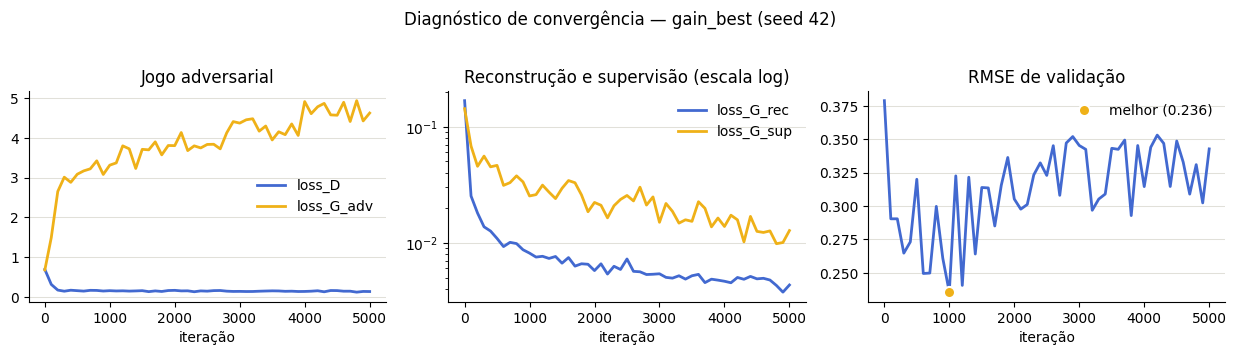

últimos 20%: CV(loss_D)=0.090 | CV(loss_G)=0.039 | loss_D média=0.145 | maior salto de loss_G=1.353
convergência: OK


In [4]:
# Estabilidade dos últimos 20% do treino
ult20 = training_log[training_log["iteracao"] > 0.8 * hp["n_iter"]]
cv_loss_d = float(ult20["loss_D"].std() / ult20["loss_D"].mean())
cv_loss_g = float(ult20["loss_G"].std() / ult20["loss_G"].mean())
salto_max = float(training_log["loss_G"].diff().abs().max())
d_final = float(ult20["loss_D"].mean())
conv_ok = (cv_loss_d < 0.25) and (cv_loss_g < 0.25) and (d_final > 0.02)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
ax = axes[0]
ax.plot(training_log["iteracao"], training_log["loss_D"], color=AZUL, lw=2, label="loss_D")
ax.plot(training_log["iteracao"], training_log["loss_G_adv"], color=LARANJA, lw=2, label="loss_G_adv")
ax.set_title("Jogo adversarial")
ax.legend(frameon=False)

ax = axes[1]
ax.plot(training_log["iteracao"], training_log["loss_G_rec"], color=AZUL, lw=2, label="loss_G_rec")
ax.plot(training_log["iteracao"], training_log["loss_G_sup"], color=LARANJA, lw=2, label="loss_G_sup")
ax.set_yscale("log")
ax.set_title("Reconstrução e supervisão (escala log)")
ax.legend(frameon=False)

ax = axes[2]
ax.plot(training_log["iteracao"], training_log["rmse_val"], color=AZUL, lw=2)
ax.plot(melhor["iteracao"], melhor["rmse_val"], "o", ms=8, color=LARANJA,
        mec="white", mew=1.5, label=f"melhor ({melhor['rmse_val']:.3f})")
ax.set_title("RMSE de validação")
ax.legend(frameon=False)

for ax in axes:
    ax.set_xlabel("iteração")
    ax.grid(axis="y", color=GRADE, lw=0.75)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Diagnóstico de convergência — gain_best (seed 42)", y=1.03)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / "diag_loss_final.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"últimos 20%: CV(loss_D)={cv_loss_d:.3f} | CV(loss_G)={cv_loss_g:.3f} | "
      f"loss_D média={d_final:.3f} | maior salto de loss_G={salto_max:.3f}")
print(f"convergência: {'OK' if conv_ok else 'ATENÇÃO'}")

**Leitura.** Reprodutibilidade exata (diff < 1e-6) — o pipeline é auditável de ponta a ponta. As perdas são estáveis nos últimos 20% (CV de 0,090 e 0,039) e `loss_D` ≈ 0,145 fica longe de zero: o jogo adversarial não colapsou. O padrão a registrar está no painel esquerdo: `loss_G_adv` **sobe** de ~0,7 para ~4,6 ao longo do treino — o discriminador vai vencendo o jogo gradualmente, enquanto reconstrução e supervisão caem monotonicamente. O resultado líquido é a curva do RMSE: mínimo cedo (0,2355 na iteração 1000) e degradação suave depois, conforme o gradiente adversarial ganha peso relativo. Nada disso é patológico para GAN-imputação, mas confirma que o **early stopping implícito é peça estrutural** do pipeline, não conveniência — sem ele, o modelo entregue seria o da iteração 5000 (RMSE ~0,34).

## Células diagnósticas — verdade conhecida, 3 seeds do protocolo

Toda a sanidade visual usa este conjunto: para cada seed do protocolo da Etapa 3 (42, 7, 2026), escondemos células observadas com `B` (`miss_rate=0,20`), imputamos com o `gain_best` e registramos `(real, imputado)` no espaço normalizado, com variável e estação. O erro é definido como **imputado − real** (positivo = superestimação).

In [5]:
SEEDS_PROTO = [42, 7, 2026]
registros = []
for s in SEEDS_PROTO:
    B_s = generate_artificial_mask(mask_real_val, miss_rate=0.20, seed=s)
    b_s = torch.tensor(B_s.to_numpy(dtype=np.float32))
    m_eff = m_val * b_s
    with torch.no_grad():
        x_imp = gain.impute(G, x_val, m_eff, ctx_val)
    escond = (m_val == 1) & (b_s == 0)
    for r, c in zip(*[t.tolist() for t in torch.where(escond)]):
        registros.append({"seed": s, "variavel": VARS[c],
                          "estacao": estacao_val.iloc[r],
                          "real": float(x_val[r, c]), "imputado": float(x_imp[r, c])})

cel = pd.DataFrame(registros)
cel["erro"] = cel["imputado"] - cel["real"]
print(f"células diagnósticas: {len(cel)} (3 seeds × val)")
cel.groupby("variavel", sort=False)["erro"].agg(n="size", media="mean", mediana="median").round(4)

células diagnósticas: 182 (3 seeds × val)


,n,media,mediana
variavel,,,
Fósforo Total,17,0.0192,0.0431
Temperatura da Água,19,0.0199,0.0313
pH,24,0.0144,0.0235
Nitrogênio Amoniacal Total,27,0.0277,0.0257
Condutividade,17,-0.1065,-0.1585
Turbidez,26,-0.0979,-0.1224
Nitrato,4,-0.1761,-0.1194
DBO,21,-0.0702,-0.0531
Sólidos Suspensos Totais,9,0.3460,0.4874


## Sanidade visual — real × imputado

Um painel por variável, com a linha $y=x$ como referência. Pontos sobre a linha = imputação perfeita; nuvem horizontal (imputado constante) = colapso à média; deslocamento sistemático = viés. O `r` anotado é a correlação de Pearson real–imputado.

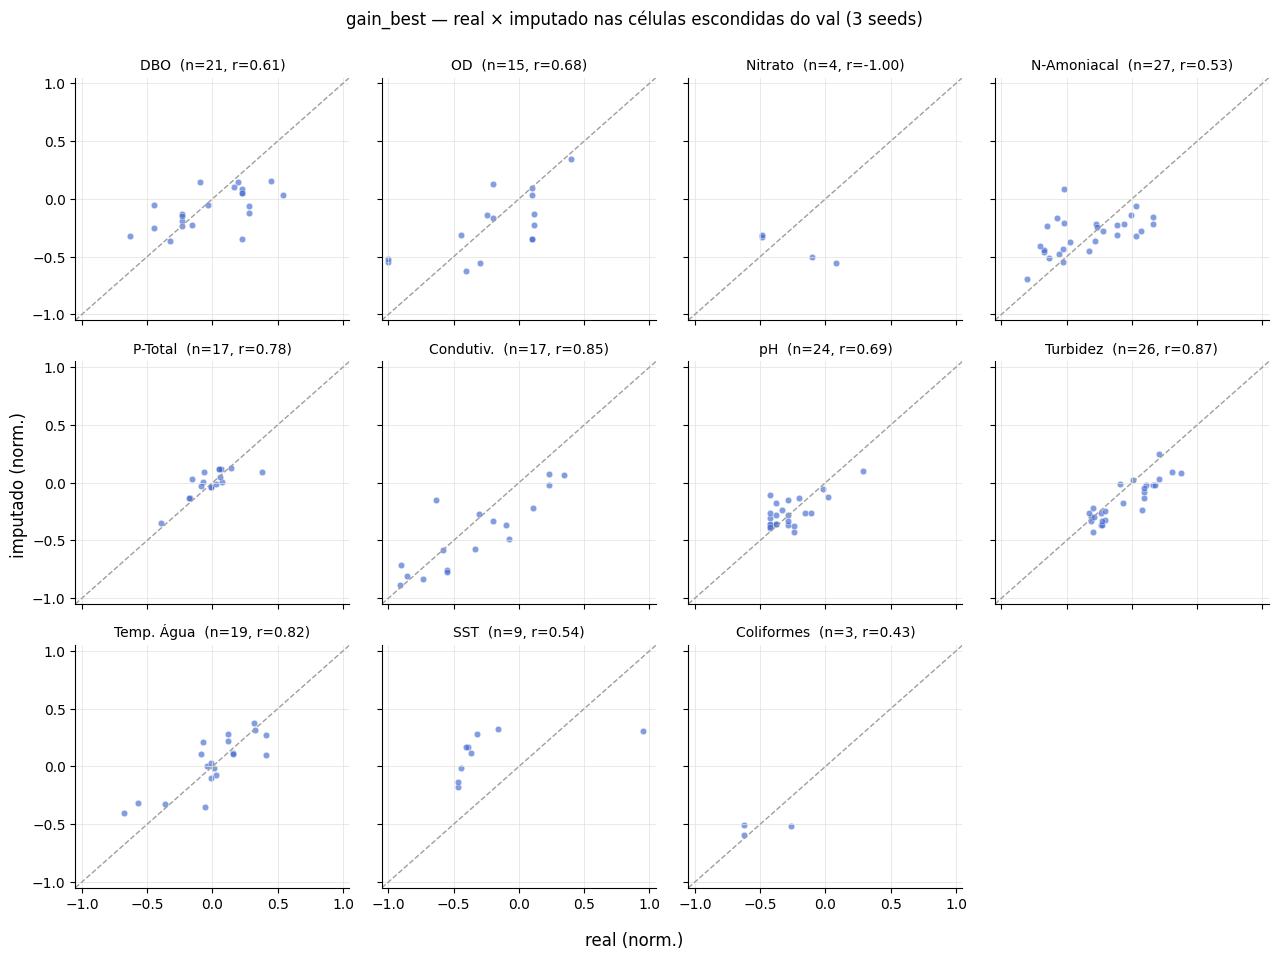

variavel
Fósforo Total                 0.7770
Temperatura da Água           0.8150
pH                            0.6940
Nitrogênio Amoniacal Total    0.5300
Condutividade                 0.8530
Turbidez                      0.8680
Nitrato                      -0.9970
DBO                           0.6130
Sólidos Suspensos Totais      0.5370
OD                            0.6820
Coliformes Termotolerantes    0.4280


In [6]:
fig, axes = plt.subplots(3, 4, figsize=(13, 9.5), sharex=True, sharey=True)
lim = (-1.05, 1.05)
for ax, var in zip(axes.ravel(), VARS):
    sub = cel[cel["variavel"] == var]
    ax.plot(lim, lim, "--", color=CINZA, lw=1)
    ax.scatter(sub["real"], sub["imputado"], s=22, color=AZUL, alpha=0.65,
               edgecolors="white", linewidths=0.4)
    r = sub["real"].corr(sub["imputado"]) if len(sub) > 2 else np.nan
    ax.set_title(f"{ABREV[var]}  (n={len(sub)}, r={r:.2f})", fontsize=10)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.grid(color=GRADE, lw=0.5)
    ax.spines[["top", "right"]].set_visible(False)
axes.ravel()[-1].axis("off")
fig.supxlabel("real (norm.)"); fig.supylabel("imputado (norm.)")
fig.suptitle("gain_best — real × imputado nas células escondidas do val (3 seeds)", y=1.0)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / "diag_scatter_real_imputado.png", dpi=150, bbox_inches="tight")
plt.show()

correl = (cel.groupby("variavel", sort=False)
          .apply(lambda g: g["real"].corr(g["imputado"]), include_groups=False)
          .rename("r_pearson"))
print(correl.round(3).to_string())

**Leitura.** Três grupos:

- **Bem imputadas** — Turbidez (r=0,87), Condutividade (0,85), Temp. Água (0,82), P-Total (0,78): nuvens inclinadas acompanhando $y=x$. Note que Condutividade tem *alta correlação mas viés* (nuvem paralela abaixo da linha) — o modelo ordena bem os casos, só desloca o nível; isso reaparece no boxplot de resíduos.
- **Intermediárias** — pH (0,69), OD (0,68), DBO (0,61), N-Amoniacal (0,53): acertam o nível, mas comprimem a escala (nuvens mais achatadas que a diagonal) — o encolhimento de variância esperado de um modelo selecionado por RMSE.
- **Frágeis** — SST (0,54, n=9): as imputações vivem num range estreito (~−0,2 a +0,35) quase independente do real; o ponto com real ≈ 0,95 é imputado em ~0,3 — o modelo não reproduz extremos de SST. Nitrato (n=4, r=−1,00): com 4 pontos o r não tem valor estatístico, mas o sinal negativo é consistente com o notebook 2 (única variável em que o KNN venceu além da Condutividade). Coliformes (n=3): sem leitura possível.

## Distribuições — observado vs imputado nas células realmente faltantes

Agora o uso de produção: imputar as células **realmente faltantes** do val (`M=0`, sem verdade conhecida) e comparar a distribuição imputada com a dos valores observados. Duas ressalvas de leitura: (1) sob MNAR as duas distribuições **não precisam** coincidir — censura e falha de coleta não são aleatórias; (2) o que procuramos são padrões grosseiros: imputações fora do suporte real, ou concentradas num único valor (mode collapse).

A razão $\sigma_{imp}/\sigma_{obs}$ anotada é o indicador de encolhimento de variância — valores muito abaixo de 1 indicam regressão à média.

C:\Users\jhter\OneDrive\Documents\QualiAgua\venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


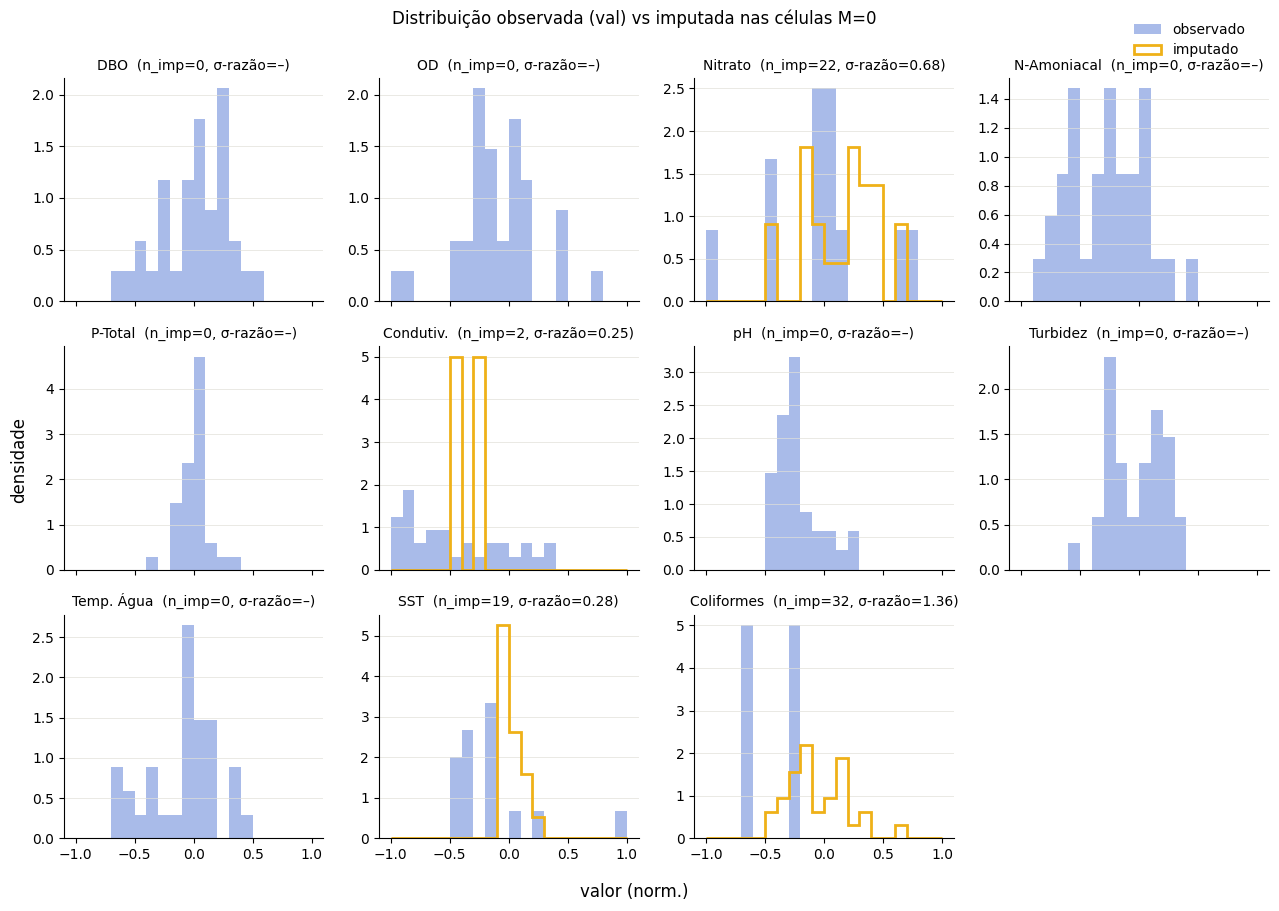

razão σ_imp/σ_obs por variável (encolhimento de variância se << 1):
Nitrato                      0.6840
Condutividade                0.2460
Sólidos Suspensos Totais     0.2790
Coliformes Termotolerantes   1.3560


In [7]:
with torch.no_grad():
    x_imp_prod = gain.impute(G, x_val, m_val, ctx_val)

fig, axes = plt.subplots(3, 4, figsize=(13, 9), sharex=True)
razao_std = {}
bins = np.linspace(-1, 1, 21)
for ax, (j, var) in zip(axes.ravel(), enumerate(VARS)):
    obs = x_val[:, j][m_val[:, j] == 1].numpy()
    imp = x_imp_prod[:, j][m_val[:, j] == 0].numpy()
    razao_std[var] = float(imp.std() / obs.std()) if len(imp) > 1 and obs.std() > 0 else np.nan
    ax.hist(obs, bins=bins, density=True, color=AZUL, alpha=0.45, label="observado")
    ax.hist(imp, bins=bins, density=True, histtype="step", color=LARANJA, lw=2,
            label="imputado")
    rot = f"{razao_std[var]:.2f}" if not np.isnan(razao_std[var]) else "–"
    ax.set_title(f"{ABREV[var]}  (n_imp={len(imp)}, σ-razão={rot})", fontsize=10)
    ax.grid(axis="y", color=GRADE, lw=0.5)
    ax.spines[["top", "right"]].set_visible(False)
axes.ravel()[-1].axis("off")
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=False, bbox_to_anchor=(0.98, 1.0))
fig.supxlabel("valor (norm.)"); fig.supylabel("densidade")
fig.suptitle("Distribuição observada (val) vs imputada nas células M=0", y=1.0)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / "diag_distrib_imputada.png", dpi=150, bbox_inches="tight")
plt.show()

razao_std_s = pd.Series(razao_std, name="razao_std").dropna()
print("razão σ_imp/σ_obs por variável (encolhimento de variância se << 1):")
print(razao_std_s.round(3).to_string())

**Leitura.** As 75 células realmente faltantes do val se concentram em **4 variáveis** — Coliformes (32), Nitrato (22), SST (19) e Condutividade (2); as outras sete estão completas no val (painéis sem curva laranja). São exatamente as variáveis de cobertura crítica/censura identificadas na EDA — ou seja, é nelas que a imputação de produção vai de fato trabalhar.

- **Nenhuma imputação fora do suporte observado** e nenhuma massa concentrada num único bin — o padrão grosseiro de colapso não aparece.
- **Nitrato** (σ-razão 0,68): forma razoável, deslocada para a direita do observado. Sob MNAR isso não é automaticamente erro — as faltas de Nitrato não são aleatórias — mas fica registrado para a Etapa 5.
- **SST** (σ-razão 0,28): pico estreito perto de 0, sem reproduzir a cauda direita do observado — o encolhimento de variância mais severo, coerente com o scatter.
- **Coliformes** (σ-razão 1,36): imputado *mais* espalhado que o observado e deslocado para cima; o observado tem só um punhado de valores (picos em ~−0,7 e ~−0,3), então a comparação é frágil — mas é a variável com mais células imputadas em produção, outra pendência para a Etapa 5.
- **Condutividade**: n_imp=2, sem leitura.

## Erro por variável

Boxplot dos resíduos (imputado − real, espaço normalizado) nas células diagnósticas. Mediana longe de zero = viés sistemático; caixa larga = variável ruidosa.

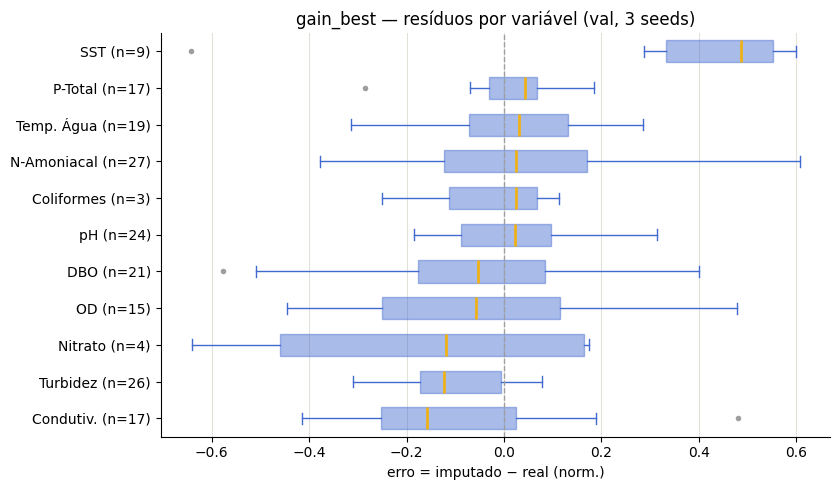

variáveis com |viés mediano| > 0,10 (e n≥5): ['Condutividade', 'Turbidez', 'Sólidos Suspensos Totais']


,n,vies_medio,vies_mediano,erro_abs_medio
variavel,,,,
Fósforo Total,17,0.0192,0.0431,0.0761
Temperatura da Água,19,0.0199,0.0313,0.1323
pH,24,0.0144,0.0235,0.1032
Nitrogênio Amoniacal Total,27,0.0277,0.0257,0.2013
Condutividade,17,-0.1065,-0.1585,0.1991
Turbidez,26,-0.0979,-0.1224,0.1210
Nitrato,4,-0.1761,-0.1194,0.3438
DBO,21,-0.0702,-0.0531,0.2015
Sólidos Suspensos Totais,9,0.3460,0.4874,0.4888


In [8]:
ordem_vars = (cel.groupby("variavel")["erro"].median().sort_values().index.tolist())
dados = [cel.loc[cel["variavel"] == v, "erro"] for v in ordem_vars]

fig, ax = plt.subplots(figsize=(8.5, 5))
bp = ax.boxplot(dados, vert=False, patch_artist=True, widths=0.6,
                tick_labels=[f"{ABREV[v]} (n={len(d)})" for v, d in zip(ordem_vars, dados)],
                boxprops=dict(facecolor=AZUL, alpha=0.45, edgecolor=AZUL),
                medianprops=dict(color=LARANJA, lw=2),
                whiskerprops=dict(color=AZUL), capprops=dict(color=AZUL),
                flierprops=dict(marker="o", ms=4, mfc=CINZA, mec="none"))
ax.axvline(0, color=CINZA, ls="--", lw=1)
ax.set_xlabel("erro = imputado − real (norm.)")
ax.set_title("gain_best — resíduos por variável (val, 3 seeds)")
ax.grid(axis="x", color=GRADE, lw=0.75)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / "diag_erro_por_variavel.png", dpi=150, bbox_inches="tight")
plt.show()

vies = cel.groupby("variavel", sort=False)["erro"].agg(
    n="size", vies_medio="mean", vies_mediano="median",
    erro_abs_medio=lambda e: e.abs().mean())
vars_problema = vies[(vies["vies_mediano"].abs() > 0.10) & (vies["n"] >= 5)].index.tolist()
print(f"variáveis com |viés mediano| > 0,10 (e n≥5): {vars_problema or 'nenhuma'}")
vies.round(4)

**Leitura.** Oito das onze variáveis têm viés mediano dentro de ±0,06 — sem viés relevante. As três sinalizadas:

- **SST: +0,49** — o viés dominante do modelo. As células escondidas de SST estavam na parte baixa do suporte e o modelo imputa sistematicamente acima (o comportamento "média condicional" visto no scatter). Nuance importante: SST é a variável em que a GAIN **mais ganha** do KNN em RMSE (0,505 vs 0,573) — "problemática" aqui significa *com viés a documentar*, não *pior que a alternativa disponível*.
- **Condutividade: −0,16** e **Turbidez: −0,12** — subestimação moderada, com boa correlação (0,85 e 0,87): erro de nível, não de ordenação.
- Nitrato tem a maior caixa do gráfico, mas com n=4 é incerteza amostral, não viés estimável.

## Erro por estação

Resíduos de todas as variáveis agrupados por estação de coleta. O condicionamento em one-hot de estação deveria tornar o erro homogêneo; uma estação com mediana deslocada ou caixa muito maior indica que o modelo a atende pior.

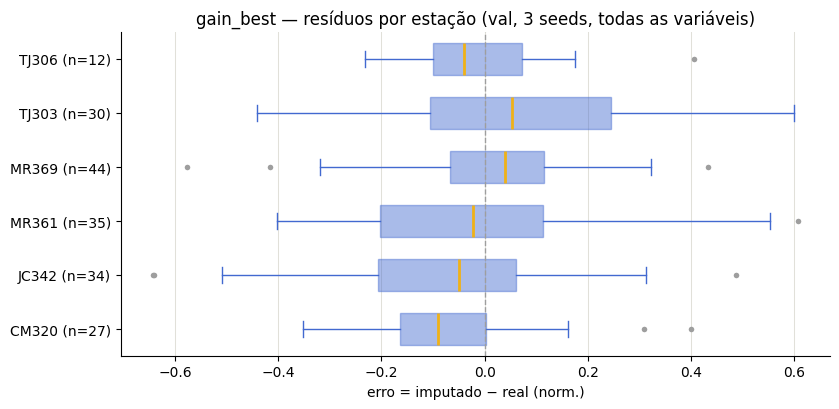

|erro| mediano global: 0.1299
estações com |erro| mediano > 1,5× o global: nenhuma


,n,vies_mediano,erro_abs_mediano
estacao,,,
CM320,27,-0.0896,0.1286
JC342,34,-0.0489,0.1724
MR361,35,-0.0223,0.1850
MR369,44,0.0388,0.1103
TJ303,30,0.0522,0.1288
TJ306,12,-0.0408,0.1147


In [9]:
ordem_est = sorted(cel["estacao"].unique())
dados_est = [cel.loc[cel["estacao"] == e, "erro"] for e in ordem_est]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.boxplot(dados_est, vert=False, patch_artist=True, widths=0.6,
           tick_labels=[f"{e} (n={len(d)})" for e, d in zip(ordem_est, dados_est)],
           boxprops=dict(facecolor=AZUL, alpha=0.45, edgecolor=AZUL),
           medianprops=dict(color=LARANJA, lw=2),
           whiskerprops=dict(color=AZUL), capprops=dict(color=AZUL),
           flierprops=dict(marker="o", ms=4, mfc=CINZA, mec="none"))
ax.axvline(0, color=CINZA, ls="--", lw=1)
ax.set_xlabel("erro = imputado − real (norm.)")
ax.set_title("gain_best — resíduos por estação (val, 3 seeds, todas as variáveis)")
ax.grid(axis="x", color=GRADE, lw=0.75)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / "diag_erro_por_estacao.png", dpi=150, bbox_inches="tight")
plt.show()

por_est = cel.groupby("estacao")["erro"].agg(
    n="size", vies_mediano="median", erro_abs_mediano=lambda e: e.abs().median())
mediana_global = float(cel["erro"].abs().median())
est_problema = por_est[por_est["erro_abs_mediano"] > 1.5 * mediana_global].index.tolist()
print(f"|erro| mediano global: {mediana_global:.4f}")
print(f"estações com |erro| mediano > 1,5× o global: {est_problema or 'nenhuma'}")
por_est.round(4)

**Leitura.** Homogêneo — nenhuma estação cruza o limiar de 1,5× o |erro| mediano global (0,130). As medianas variam de −0,09 (CM320, leve subestimação) a +0,05 (TJ303), e o |erro| mediano por estação fica entre 0,110 e 0,185. TJ303 tem a maior dispersão e TJ306 o menor n (12 células). O one-hot de estação está cumprindo o papel: o modelo não favorece nem abandona nenhum ponto da lagoa.

## Checagem de mode collapse

Duas medidas complementares:

1. **Sensibilidade ao ruído $Z$** (o que o plano pede): imputamos as mesmas células faltantes do val 50 vezes, variando só o ruído $Z \sim U(-0{,}01, 0{,}01)$ das células mascaradas, e medimos o desvio-padrão por célula. **Atenção à leitura**: perto de zero *não* é colapso aqui — o gerador foi treinado para ser robusto ao ruído (a inferência do notebook 1 é deliberadamente determinística); esta medida só confirma esse comportamento.
2. **Diversidade entre amostras** (o indicador que de fato acusa colapso em imputação): se as imputações de células diferentes fossem quase constantes por variável ($\sigma_{imp}/\sigma_{obs} \approx 0$, tabela da seção de distribuições), o modelo estaria ignorando o contexto e chutando a média incondicional. A correlação real–imputado do scatter fecha o argumento: colapso à média incondicional implicaria $r \approx 0$.

In [10]:
K = 50
g_z = torch.Generator().manual_seed(SEED)
amostras = []
with torch.no_grad():
    for _ in range(K):
        z = (torch.rand(x_val.shape, generator=g_z) - 0.5) * 0.02
        x_tilde = m_val * x_val + (1.0 - m_val) * z
        x_bar = G(x_tilde, ctx_val, m_val)
        amostras.append(x_bar)
pilha = torch.stack(amostras)                      # (K, n_val, n_vars)
std_z = pilha.std(dim=0)[m_val == 0]               # std por célula faltante

sigma_medio, sigma_max = float(std_z.mean()), float(std_z.max())
razao_mediana = float(razao_std_s.median())
r_mediana = float(correl.median())
colapso = razao_mediana < 0.30 or r_mediana < 0.30

print(f"1) sensibilidade ao ruído Z (K={K}): σ médio por célula = {sigma_medio:.4f} | "
      f"máximo = {sigma_max:.4f}")
print(f"   (esperado ≈ 0: o G é treinado para imputação determinística)")
print(f"2) diversidade entre amostras: mediana de σ_imp/σ_obs = {razao_mediana:.3f} | "
      f"mediana de r real-imputado = {r_mediana:.3f}")
print(f"\nmode collapse: {'DETECTADO' if colapso else 'não detectado'} "
      f"(critério: razão-σ mediana < 0,30 ou r mediano < 0,30)")

1) sensibilidade ao ruído Z (K=50): σ médio por célula = 0.0050 | máximo = 0.0080
   (esperado ≈ 0: o G é treinado para imputação determinística)
2) diversidade entre amostras: mediana de σ_imp/σ_obs = 0.482 | mediana de r real-imputado = 0.682

mode collapse: não detectado (critério: razão-σ mediana < 0,30 ou r mediano < 0,30)


## Relatório — `diagnostico.md`

Consolida os achados computados acima em um relatório narrativo curto, com o veredicto explícito. O texto é gerado a partir das variáveis do notebook — os números não podem divergir das figuras.

In [11]:
hoje = pd.Timestamp.today().strftime("%Y-%m-%d")
v_probs = ", ".join(vars_problema) if vars_problema else "nenhuma"
e_probs = ", ".join(est_problema) if est_problema else "nenhuma"
veredicto = ("**AVANÇAR para a Etapa 5 (05_Evaluation)**"
             if conv_ok and not colapso and config_best["criterio_aceite_ok"]
             else "**VOLTAR ao 02_hyperparam.ipynb**")

relatorio = f'''# Diagnóstico do modelo final — gain_best

*Gerado por `03_diagnostico.ipynb` em {hoje}. Modelo: `{config_best["config_id"]}`
(hint_rate={hp["hint_rate"]}, alpha={hp["alpha"]:.0f}, beta={hp["beta"]:.0f},
batch={hp["batch_size"]}, hidden={hp["hidden"]}, lr_g={hp["lr_g"]}, lr_d={hp["lr_d"]}),
seed {ckpt["seed"]}, melhor iteração {ckpt["iteracao_melhor"]}.*

## 1. Convergência: {"OK" if conv_ok else "ATENÇÃO"}

Retreino determinístico reproduz o checkpoint ({"diff < 1e-6" if reproduzivel else f"DIVERGIU: diff={diff:.2e}"}).
Últimos 20% do treino: CV(loss_D) = {cv_loss_d:.3f}, CV(loss_G) = {cv_loss_g:.3f},
loss_D média = {d_final:.3f} (sem colapso do jogo adversarial: D não domina).
Melhor RMSE_val = {float(melhor["rmse_val"]):.4f} na iteração {int(melhor["iteracao"])};
o early stopping implícito do `train_gain` é quem garante o uso desse ponto.

## 2. Mode collapse: {"DETECTADO" if colapso else "não detectado"}

- Diversidade entre amostras: mediana de sigma_imp/sigma_obs = {razao_mediana:.3f};
  mediana da correlação real-imputado = {r_mediana:.3f}.
- Sensibilidade ao ruído Z (K={K}): sigma médio por célula = {sigma_medio:.4f}
  (≈ 0 é o esperado — o gerador é treinado como imputador determinístico).

## 3. Variáveis problemáticas: {v_probs}

Critério: |viés mediano| > 0,10 no espaço normalizado com n ≥ 5 células.
Menores correlações real-imputado: {", ".join(f"{ABREV[v]} (r={correl[v]:.2f})" for v in correl.nsmallest(3).index)}.

## 4. Estações problemáticas: {e_probs}

Critério: |erro| mediano > 1,5× o |erro| mediano global ({mediana_global:.3f}).

## 5. Veredicto: {veredicto}

Critério de aceite da etapa já atendido no notebook 2 (RMSE_norm {config_best["rmse_val_protocolo_etapa3"]:.4f}
vs {config_best["rmse_val_knn_protocolo"]:.4f} do KNN no val). Este diagnóstico
{"não encontrou patologia que invalide o resultado" if conv_ok and not colapso else "encontrou problemas que precisam ser tratados antes de avançar"}.
'''

OUT_RELATORIO.write_text(relatorio, encoding="utf-8")
print(f"relatório salvo: {OUT_RELATORIO}\n")
print(relatorio)

relatório salvo: ..\..\Data\GainResults\diagnostico.md

# Diagnóstico do modelo final — gain_best

*Gerado por `03_diagnostico.ipynb` em 2026-07-07. Modelo: `cfg_1092`
(hint_rate=0.9, alpha=10, beta=10,
batch=128, hidden=[128, 128], lr_g=0.001, lr_d=0.001),
seed 42, melhor iteração 1000.*

## 1. Convergência: OK

Retreino determinístico reproduz o checkpoint (diff < 1e-6).
Últimos 20% do treino: CV(loss_D) = 0.090, CV(loss_G) = 0.039,
loss_D média = 0.145 (sem colapso do jogo adversarial: D não domina).
Melhor RMSE_val = 0.2355 na iteração 1000;
o early stopping implícito do `train_gain` é quem garante o uso desse ponto.

## 2. Mode collapse: não detectado

- Diversidade entre amostras: mediana de sigma_imp/sigma_obs = 0.482;
  mediana da correlação real-imputado = 0.682.
- Sensibilidade ao ruído Z (K=50): sigma médio por célula = 0.0050
  (≈ 0 é o esperado — o gerador é treinado como imputador determinístico).

## 3. Variáveis problemáticas: Condutividade, Turbidez, Sólidos Suspensos 

## Síntese final

### Veredicto: **AVANÇAR para a Etapa 5** ✅

O `gain_best` passou no atestado de sanidade. Resumo por patologia:

| Patologia checada | Resultado | Evidência |
|---|---|---|
| Não-convergência / oscilação | **OK** | CV(loss_D)=0,090, CV(loss_G)=0,039 nos últimos 20%; reprodutível (diff < 1e-6) |
| Dominância do D | **OK, com nota** | `loss_D`≈0,145 (não colapsa), mas `loss_G_adv` sobe 0,7→4,6 — o early stopping implícito (iter 1000) é estrutural |
| Mode collapse | **Não detectado** | σ_imp/σ_obs mediana 0,48; r real–imputado mediano 0,68; imputações dentro do suporte |
| Encolhimento de variância | **Presente, esperado** | Consequência da seleção por RMSE (+`beta`); severo em SST (σ-razão 0,28) |
| Viés sistemático | **3 variáveis** | SST +0,49, Condutividade −0,16, Turbidez −0,12 (mediana, norm.); estações homogêneas |

### O que o diagnóstico acrescenta ao RMSE do notebook 2

1. **A imputação de produção trabalha em 4 variáveis** — Coliformes, Nitrato, SST e Condutividade concentram 100% das células realmente faltantes do val. A sorte do projeto: em Coliformes e SST a GAIN é justamente onde mais ganha do KNN; a fragilidade fica em Nitrato (r negativo nas células diagnósticas, ainda que com n=4).
2. **O modelo erra "para dentro"**: comprime caudas e regride à média condicional — certo em nível, conservador em extremos. Para o uso downstream (série imputada para análise de tendência), isso é aceitável; para detecção de eventos extremos, seria uma limitação a declarar.
3. **Nenhuma estação é desfavorecida** — o condicionamento espacial funciona.

### Critério de aceite do notebook

- ✅ 5 figuras geradas (`diag_loss_final`, `diag_scatter_real_imputado`, `diag_distrib_imputada`, `diag_erro_por_variavel`, `diag_erro_por_estacao`).
- ✅ `Data/GainResults/diagnostico.md` responde às 5 perguntas (convergência, collapse, variáveis, estações, veredicto).
- ✅ Veredicto explícito: **avançar** (critério de RMSE já atendido no notebook 2; nenhuma patologia invalidante).

### Pendências levadas para a Etapa 5

- Confirmar o ganho no **test** com o mesmo protocolo (referência: KNN 0,313).
- Olhar **Nitrato** e **Coliformes** com atenção — são as variáveis com mais imputação de produção e menor evidência no val.
- Se alguma análise downstream depender da distribuição (não só do valor pontual), considerar o viés de SST e o encolhimento de caudas documentados aqui.

## Fim da Etapa 4

Próximo: `05_Evaluation/01_pontual.ipynb`.